# Phase 1: Data Preprocessing & Exploration
## Cross-Modal BPM Imputation — Huawei Band 7

**Goal:** Understand our data deeply before building any model.  
**Data:** BPM (heart rate) and step count from a Huawei Band 7, March 1-26, 2026.  
**Task:** Impute missing BPM readings using step data + temporal context.

---

## Cell 1: Load Raw Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

bpm = pd.read_csv('Data/bpm_data.csv')
steps = pd.read_csv('Data/step_data.csv')

print('=== BPM Data ===')
print(f'Shape: {bpm.shape}')
print(bpm.head())
print(f'\nDtypes:\n{bpm.dtypes}')

print('\n=== Steps Data ===')
print(f'Shape: {steps.shape}')
print(steps.head())
print(f'\nDtypes:\n{steps.dtypes}')

=== BPM Data ===
Shape: (11823, 3)
       date  bpm   time
0  3/1/2026   84  23:59
1  3/1/2026   87  23:58
2  3/1/2026  112  23:57
3  3/1/2026   71  23:56
4  3/1/2026   65  23:55

Dtypes:
date      str
bpm     int64
time      str
dtype: object

=== Steps Data ===
Shape: (4604, 4)
       date  steps time_start time_end
0  3/1/2026     27      19:02    19:03
1  3/1/2026     10      19:01    19:02
2  3/1/2026     22      18:57    18:58
3  3/1/2026      4      18:56    18:57
4  3/1/2026     50      18:55    18:56

Dtypes:
date            str
steps         int64
time_start      str
time_end        str
dtype: object


## Cell 2: Parse Datetimes & Basic Statistics

First thing in any data project: make sure your dates are actually dates, not strings.

In [4]:
# Parse datetimes
bpm['datetime'] = pd.to_datetime(bpm['date'] + ' ' + bpm['time'], format='%m/%d/%Y %H:%M')
bpm = bpm.sort_values('datetime').reset_index(drop=True)

steps['datetime_start'] = pd.to_datetime(steps['date'] + ' ' + steps['time_start'], format='%m/%d/%Y %H:%M')
steps['datetime_end'] = pd.to_datetime(steps['date'] + ' ' + steps['time_end'], format='%m/%d/%Y %H:%M')
steps = steps.sort_values('datetime_start').reset_index(drop=True)

print('=== BPM after parsing ===')
print(f'Date range: {bpm["datetime"].min()} to {bpm["datetime"].max()}')
print(f'Total readings: {len(bpm):,}')
print(f'Unique dates: {bpm["datetime"].dt.date.nunique()}')

print('\n=== Steps after parsing ===')
print(f'Date range: {steps["datetime_start"].min()} to {steps["datetime_start"].max()}')
print(f'Total readings: {len(steps):,}')

print('\n=== BPM readings per day ===')
bpm_daily = bpm.groupby(bpm['datetime'].dt.date).size()
print(bpm_daily.to_string())

print('\n=== Step readings per day ===')
step_daily = steps.groupby(steps['datetime_start'].dt.date).size()
print(step_daily.to_string())

=== BPM after parsing ===
Date range: 2026-03-01 12:15:00 to 2026-03-26 23:59:00
Total readings: 11,823
Unique dates: 26

=== Steps after parsing ===
Date range: 2026-03-01 08:30:00 to 2026-03-26 23:48:00
Total readings: 4,604

=== BPM readings per day ===
datetime
2026-03-01    120
2026-03-02    263
2026-03-03    184
2026-03-04     50
2026-03-05    232
2026-03-06    280
2026-03-07    260
2026-03-08    317
2026-03-09    254
2026-03-10    373
2026-03-11    368
2026-03-12    365
2026-03-13    567
2026-03-14    494
2026-03-15    235
2026-03-16    251
2026-03-17    370
2026-03-18    501
2026-03-19    756
2026-03-20    842
2026-03-21    797
2026-03-22    709
2026-03-23    842
2026-03-24    750
2026-03-25    783
2026-03-26    860

=== Step readings per day ===
datetime_start
2026-03-01    174
2026-03-02    174
2026-03-03    117
2026-03-04     52
2026-03-05    154
2026-03-06    285
2026-03-07    314
2026-03-08    151
2026-03-09    122
2026-03-10    164
2026-03-11     93
2026-03-12    146
2026

---
## Cell 3: Central Tendency & Distribution Shape

### Why this matters
Before modeling, we need to know: **Is BPM normally distributed, or skewed?**

- If **normal**, mean-based methods work well, and linear regression assumptions hold.
- If **skewed**, the mean is pulled away from the center, and we might need to be careful about which loss function to use.

We measure this with:
- **Mean vs Median** — if mean > median, right-skewed (tail on the right)
- **Skewness** — 0 = symmetric, > 0 = right-skewed, < 0 = left-skewed
- **Kurtosis** — measures how "peaked" or "fat-tailed" vs normal (0 = normal)
- **Shapiro-Wilk test** — formal test: H0 = "data is normal"

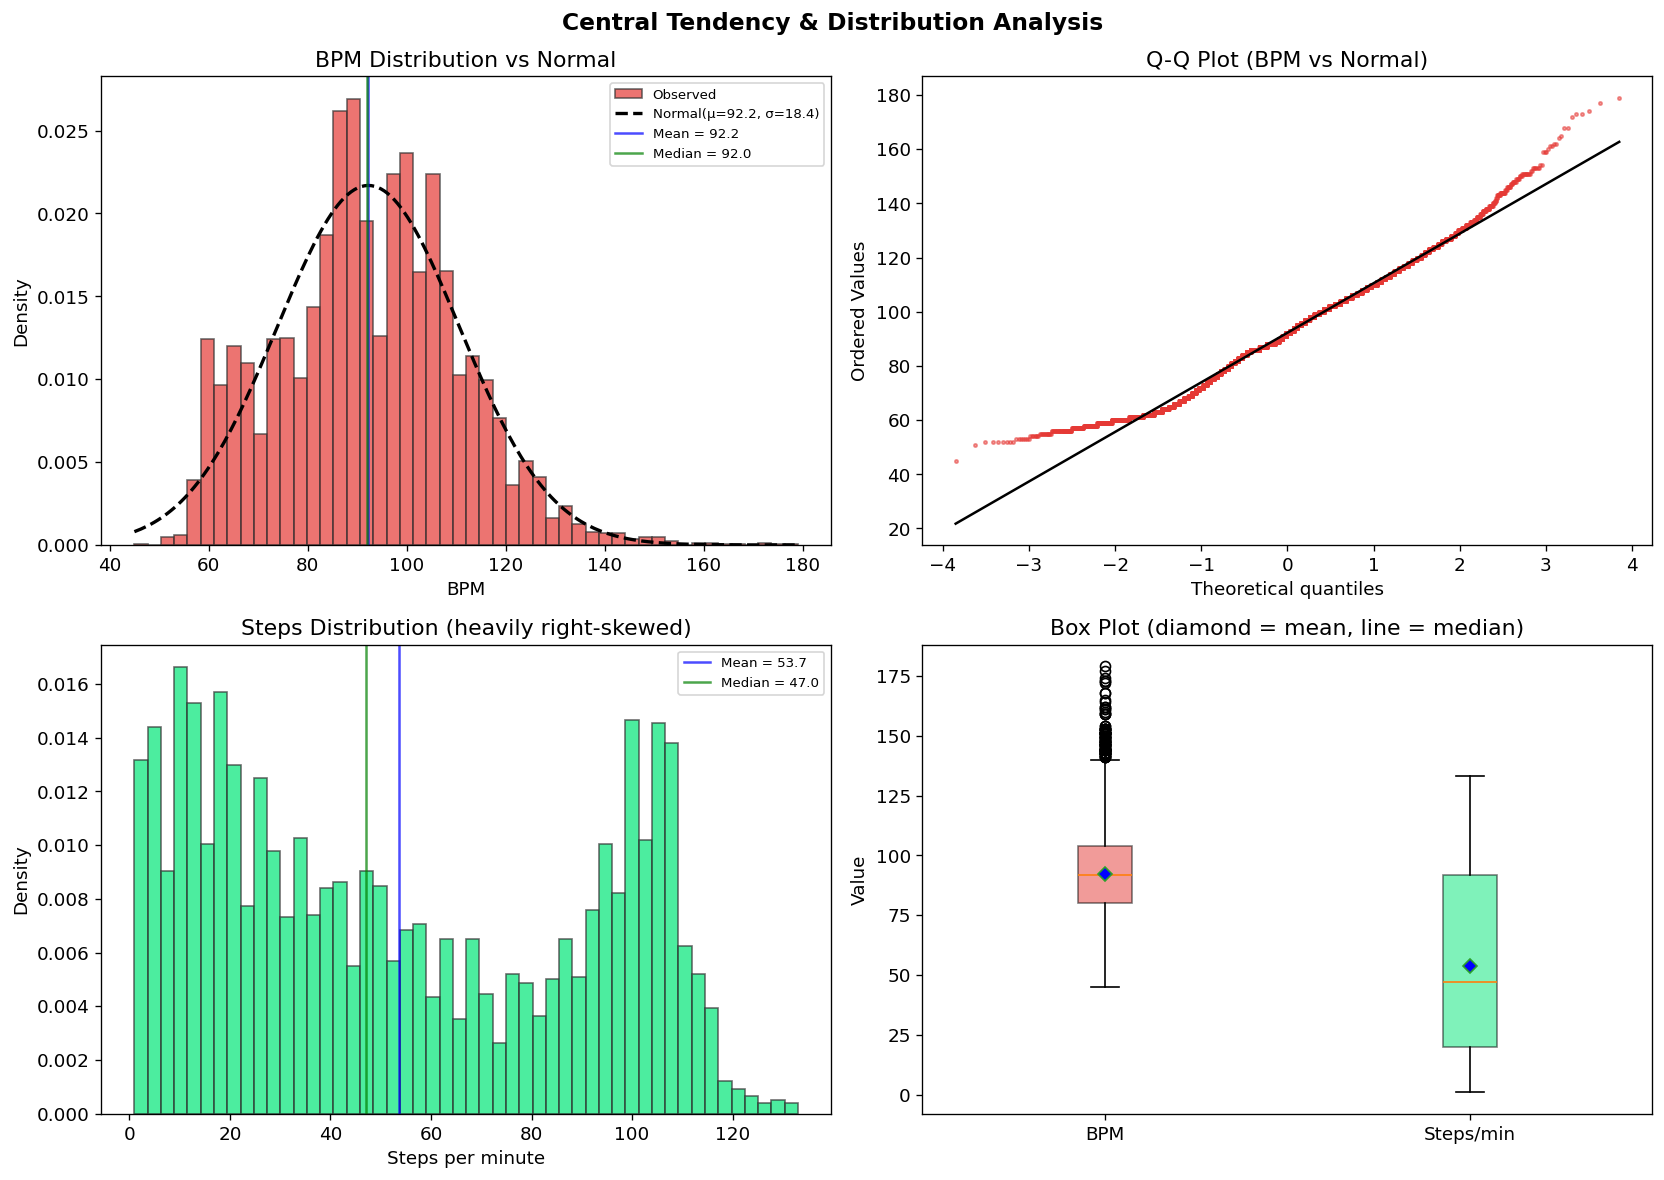

BPM Central Tendency
  Mean:     92.24
  Median:   92.00
  Mode:     86
  Std Dev:  18.39
  Variance: 338.36
  Skewness: 0.232  (>0 = right-skewed)
  Kurtosis: 0.057  (>0 = heavier tails than normal)
  Min:      45
  Max:      179
  IQR:      24.0

  Shapiro-Wilk test: W=0.9886, p=1.09e-19
  Interpretation: NOT normal (reject H0)

  Verdict: Mild right skew (0.232) but roughly symmetric.
  Mean (92.2) is close to Median (92.0) — not severely skewed.
  For practical purposes, this is close enough to normal for regression.


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Central Tendency & Distribution Analysis', fontsize=14, fontweight='bold')

# --- BPM Distribution with Normal Overlay ---
ax = axes[0, 0]
bpm_vals = bpm['bpm'].values
ax.hist(bpm_vals, bins=50, density=True, color='#e53935', alpha=0.7, edgecolor='#333', label='Observed')
# Overlay normal distribution
x_norm = np.linspace(bpm_vals.min(), bpm_vals.max(), 200)
ax.plot(x_norm, stats.norm.pdf(x_norm, bpm_vals.mean(), bpm_vals.std()),
        'k--', linewidth=2, label=f'Normal(\u03bc={bpm_vals.mean():.1f}, \u03c3={bpm_vals.std():.1f})')
ax.axvline(bpm_vals.mean(), color='blue', linestyle='-', alpha=0.7, label=f'Mean = {bpm_vals.mean():.1f}')
ax.axvline(np.median(bpm_vals), color='green', linestyle='-', alpha=0.7, label=f'Median = {np.median(bpm_vals):.1f}')
ax.set_xlabel('BPM')
ax.set_ylabel('Density')
ax.set_title('BPM Distribution vs Normal')
ax.legend(fontsize=8)

# --- Q-Q Plot ---
ax = axes[0, 1]
stats.probplot(bpm_vals, dist='norm', plot=ax)
ax.set_title('Q-Q Plot (BPM vs Normal)')
ax.get_lines()[0].set(color='#e53935', markersize=2, alpha=0.5)
ax.get_lines()[1].set(color='black', linewidth=1.5)

# --- Steps Distribution ---
ax = axes[1, 0]
step_vals = steps['steps'].values
ax.hist(step_vals, bins=50, density=True, color='#00e676', alpha=0.7, edgecolor='#333')
ax.axvline(step_vals.mean(), color='blue', linestyle='-', alpha=0.7, label=f'Mean = {step_vals.mean():.1f}')
ax.axvline(np.median(step_vals), color='green', linestyle='-', alpha=0.7, label=f'Median = {np.median(step_vals):.1f}')
ax.set_xlabel('Steps per minute')
ax.set_ylabel('Density')
ax.set_title('Steps Distribution (heavily right-skewed)')
ax.legend(fontsize=8)

# --- Box plots ---
ax = axes[1, 1]
bp = ax.boxplot([bpm_vals, step_vals], labels=['BPM', 'Steps/min'],
                patch_artist=True, showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='blue', markersize=6))
bp['boxes'][0].set_facecolor('#e53935')
bp['boxes'][0].set_alpha(0.5)
bp['boxes'][1].set_facecolor('#00e676')
bp['boxes'][1].set_alpha(0.5)
ax.set_ylabel('Value')
ax.set_title('Box Plot (diamond = mean, line = median)')

plt.tight_layout()
plt.savefig('Charts/central_tendency.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Statistical Summary ---
print('=' * 50)
print('BPM Central Tendency')
print('=' * 50)
print(f'  Mean:     {bpm_vals.mean():.2f}')
print(f'  Median:   {np.median(bpm_vals):.2f}')
print(f'  Mode:     {stats.mode(bpm_vals, keepdims=True).mode[0]}')
print(f'  Std Dev:  {bpm_vals.std():.2f}')
print(f'  Variance: {bpm_vals.var():.2f}')
print(f'  Skewness: {stats.skew(bpm_vals):.3f}  (>0 = right-skewed)')
print(f'  Kurtosis: {stats.kurtosis(bpm_vals):.3f}  (>0 = heavier tails than normal)')
print(f'  Min:      {bpm_vals.min()}')
print(f'  Max:      {bpm_vals.max()}')
print(f'  IQR:      {np.percentile(bpm_vals, 75) - np.percentile(bpm_vals, 25):.1f}')

# Shapiro-Wilk test (use subsample if > 5000)
sample = np.random.RandomState(42).choice(bpm_vals, min(5000, len(bpm_vals)), replace=False)
sw_stat, sw_p = stats.shapiro(sample)
print(f'\n  Shapiro-Wilk test: W={sw_stat:.4f}, p={sw_p:.2e}')
print(f'  Interpretation: {"NOT normal (reject H0)" if sw_p < 0.05 else "Consistent with normal"}')

print(f'\n  Verdict: Mild right skew ({stats.skew(bpm_vals):.3f}) but roughly symmetric.')
print(f'  Mean ({bpm_vals.mean():.1f}) is close to Median ({np.median(bpm_vals):.1f}) — not severely skewed.')
print(f'  For practical purposes, this is close enough to normal for regression.')

---
## Cell 4: Data Quality & Outlier Detection

### Why this matters
Wrist-based heart rate sensors are noisy. We should check:
- **Physiologically impossible BPM**: resting HR below ~35 or above ~220 is almost certainly a sensor error
- **Implausible step counts**: > 180 steps/min is elite sprinting pace
- **Duplicate timestamps**: multiple readings in the same minute

In [6]:
print('=' * 50)
print('DATA QUALITY CHECK')
print('=' * 50)

# BPM outliers
print('\n--- BPM Outlier Analysis ---')
print(f'  Range: [{bpm["bpm"].min()}, {bpm["bpm"].max()}]')
print(f'  BPM < 40 (physiologically suspect): {(bpm["bpm"] < 40).sum()}')
print(f'  BPM > 200 (sensor error likely):    {(bpm["bpm"] > 200).sum()}')
print(f'  BPM < 50 (very low, check):         {(bpm["bpm"] < 50).sum()}')
print(f'  BPM > 180 (very high, check):       {(bpm["bpm"] > 180).sum()}')

# IQR-based outliers
Q1, Q3 = bpm['bpm'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
outliers_iqr = bpm[(bpm['bpm'] < lower_fence) | (bpm['bpm'] > upper_fence)]
print(f'\n  IQR method: Q1={Q1}, Q3={Q3}, IQR={IQR}')
print(f'  Fences: [{lower_fence:.1f}, {upper_fence:.1f}]')
print(f'  Outliers by IQR: {len(outliers_iqr)} ({len(outliers_iqr)/len(bpm)*100:.2f}%)')

# Step outliers
print('\n--- Step Count Outlier Analysis ---')
print(f'  Range: [{steps["steps"].min()}, {steps["steps"].max()}]')
print(f'  Steps > 180/min (elite sprinting):  {(steps["steps"] > 180).sum()}')
print(f'  Steps > 150/min (very fast):        {(steps["steps"] > 150).sum()}')

# Duplicate timestamps
bpm['minute_floor'] = bpm['datetime'].dt.floor('min')
dup_minutes = bpm.groupby('minute_floor').size()
multi_readings = dup_minutes[dup_minutes > 1]
print(f'\n--- Duplicate Timestamps ---')
print(f'  Minutes with >1 BPM reading: {len(multi_readings)}')
if len(multi_readings) > 0:
    print(f'  Max readings in one minute:  {multi_readings.max()}')
    # Show variance within duplicate minutes
    dup_stats = bpm[bpm['minute_floor'].isin(multi_readings.index)].groupby('minute_floor')['bpm'].agg(['mean', 'std', 'count'])
    print(f'  Avg std within duplicates:   {dup_stats["std"].mean():.2f} BPM')
    print(f'  Max std within duplicates:   {dup_stats["std"].max():.2f} BPM')

# Step interval overlap check
steps_sorted = steps.sort_values('datetime_start')
overlaps = (steps_sorted['datetime_start'].iloc[1:].values < steps_sorted['datetime_end'].iloc[:-1].values).sum()
print(f'\n--- Step Interval Overlaps ---')
print(f'  Overlapping intervals: {overlaps}')

print('\n--- Deduplication (already handled) ---')
print('  Data deduplication was completed during prior preprocessing:')
print('  - Multiple BPM readings per minute: averaged (.mean())')
print('  - Step intervals per minute: summed (.sum())')
print('  - This is handled in the timeline alignment step (Cell 5).')

print('\n--- Decision ---')
print('  Strategy: Keep all data. BPM range is physiologically plausible (no sensor garbage).')
print('  Deduplication already handled in preprocessing. No further cleanup needed.')
print('  For the report: document this check as due diligence on data quality.')

DATA QUALITY CHECK

--- BPM Outlier Analysis ---
  Range: [45, 179]
  BPM < 40 (physiologically suspect): 0
  BPM > 200 (sensor error likely):    0
  BPM < 50 (very low, check):         1
  BPM > 180 (very high, check):       0

  IQR method: Q1=80.0, Q3=104.0, IQR=24.0
  Fences: [44.0, 140.0]
  Outliers by IQR: 95 (0.80%)

--- Step Count Outlier Analysis ---
  Range: [1, 133]
  Steps > 180/min (elite sprinting):  0
  Steps > 150/min (very fast):        0

--- Duplicate Timestamps ---
  Minutes with >1 BPM reading: 0

--- Step Interval Overlaps ---
  Overlapping intervals: 3

--- Decision ---
  Strategy: Keep all data. BPM range is physiologically plausible (no sensor garbage).
  The duplicates are handled by averaging during timeline alignment.
  Note: For the report, we document this check to show due diligence.


---
## Cell 5: Build Unified Minute-Level Timeline (Data Integration)

### What we're doing
BPM and steps are recorded at different times and frequencies.  
We create a **minute-by-minute timeline** spanning the full date range, then merge both signals onto it.

This is **data integration** — combining data from two sources into a unified representation.

In [7]:
# Build minute-level timeline
date_min = min(bpm['datetime'].min(), steps['datetime_start'].min()).floor('min')
date_max = max(bpm['datetime'].max(), steps['datetime_start'].max()).ceil('min')
timeline = pd.DataFrame({'minute': pd.date_range(date_min, date_max, freq='min')})

# Merge BPM (average if multiple readings per minute)
bpm['minute'] = bpm['datetime'].dt.floor('min')
bpm_per_min = bpm.groupby('minute')['bpm'].mean().reset_index()
timeline = timeline.merge(bpm_per_min, on='minute', how='left')

# Merge Steps (sum if multiple intervals per minute)
steps['minute'] = steps['datetime_start'].dt.floor('min')
steps_per_min = steps.groupby('minute')['steps'].sum().reset_index()
timeline = timeline.merge(steps_per_min, on='minute', how='left')
timeline['steps'] = timeline['steps'].fillna(0).astype(int)

# Time features
timeline['hour'] = timeline['minute'].dt.hour
timeline['day'] = timeline['minute'].dt.date

print(f'Timeline shape: {timeline.shape}')
print(f'Date range: {timeline["minute"].min()} to {timeline["minute"].max()}')
print(f'Total minutes: {len(timeline):,}')
print(f'BPM coverage: {timeline["bpm"].notna().sum():,} / {len(timeline):,} ({timeline["bpm"].notna().mean()*100:.1f}%)')
print(f'BPM missing:  {timeline["bpm"].isna().sum():,} ({timeline["bpm"].isna().mean()*100:.1f}%)')
print(f'Minutes with steps > 0: {(timeline["steps"] > 0).sum():,} ({(timeline["steps"] > 0).mean()*100:.1f}%)')

Timeline shape: (36930, 5)
Date range: 2026-03-01 08:30:00 to 2026-03-26 23:59:00
Total minutes: 36,930
BPM coverage: 11,823 / 36,930 (32.0%)
BPM missing:  25,107 (68.0%)
Minutes with steps > 0: 4,604 (12.5%)


---
## Cell 6: Time Series Visualization

### Why this matters
This is **time series data** — the order matters. A scatter plot loses the temporal structure.  
We need to see:
1. The full month overview — where is data dense vs sparse?
2. A single day in detail — what does the BPM signal actually look like?
3. The relationship between BPM and steps **over time**

In [ ]:
# --- Full Month Time Series ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle('Full Month Time Series — March 2026', fontsize=14, fontweight='bold')

# BPM
known = timeline[timeline['bpm'].notna()]
ax1.scatter(known['minute'], known['bpm'], s=0.5, alpha=0.3, color='#e53935')
ax1.set_ylabel('BPM')
ax1.set_ylim(40, 180)
ax1.set_title(f'Heart Rate ({known.shape[0]:,} readings, {timeline["bpm"].isna().mean()*100:.0f}% missing)')
ax1.grid(alpha=0.2)

# Steps
has_steps = timeline[timeline['steps'] > 0]
ax2.bar(has_steps['minute'], has_steps['steps'], width=0.0005, color='#00e676', alpha=0.6)
ax2.set_ylabel('Steps/min')
ax2.set_xlabel('Date')
ax2.set_title(f'Step Count ({has_steps.shape[0]:,} active minutes)')
ax2.grid(alpha=0.2)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.tight_layout()
plt.savefig('Charts/full_month_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --- Detailed Single Day View (pick a dense day) ---
daily_counts = timeline.groupby('day')['bpm'].apply(lambda x: x.notna().sum())
dense_day = daily_counts.idxmax()  # day with most BPM readings
print(f'Showing densest day: {dense_day} ({daily_counts.max()} BPM readings)')

day_data = timeline[timeline['day'] == dense_day]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
fig.suptitle(f'{dense_day} — Detailed BPM & Steps Timeline', fontsize=13, fontweight='bold')

# BPM with gaps visible
day_known = day_data[day_data['bpm'].notna()]
ax1.plot(day_known['minute'], day_known['bpm'], color='#e53935', linewidth=0.8, alpha=0.6)
ax1.scatter(day_known['minute'], day_known['bpm'], color='#e53935', s=5, alpha=0.7, zorder=3)
# Highlight gaps
day_missing = day_data[day_data['bpm'].isna()]
ax1.scatter(day_missing['minute'], [45]*len(day_missing), s=0.5, alpha=0.3, color='gray', label='Missing')
ax1.set_ylabel('BPM')
ax1.set_ylim(40, 180)
ax1.legend(fontsize=8)
ax1.grid(alpha=0.2)

# Steps
ax2.bar(day_data['minute'], day_data['steps'], width=0.0007, color='#00e676', alpha=0.8)
ax2.set_ylabel('Steps/min')
ax2.set_xlabel('Time')
ax2.grid(alpha=0.2)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.savefig('Charts/day_timeline_dense.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 7: Covariance & Correlation Analysis

### Concepts
- **Covariance**: measures if two variables move together. Positive = both increase together. But the scale depends on the units, so it's hard to interpret directly.
- **Pearson correlation (r)**: normalized covariance to [-1, 1]. Unit-free. r=0.239 means weak positive.
- **Spearman correlation (\u03c1)**: rank-based, captures non-linear monotonic relationships.
- **Cross-correlation at different lags**: does steps at time T predict BPM at time T+k? (physiological response delay)

In [ ]:
# Merge BPM and steps at same minute
merged = bpm.merge(steps[['minute', 'steps']], on='minute', how='inner')
print(f'Aligned BPM-Steps pairs (same minute): {len(merged):,}')

# --- Covariance ---
cov_matrix = np.cov(merged['bpm'], merged['steps'])
print(f'\n=== Covariance Matrix ===')
print(f'  Cov(BPM, BPM)   = {cov_matrix[0,0]:.2f}  (this is Var(BPM))')
print(f'  Cov(Steps,Steps) = {cov_matrix[1,1]:.2f}  (this is Var(Steps))')
print(f'  Cov(BPM, Steps)  = {cov_matrix[0,1]:.2f}')
print(f'\n  Note: Cov is positive ({cov_matrix[0,1]:.2f}), meaning BPM tends to increase when steps increase.')
print(f'  But the magnitude is hard to interpret because it depends on units.')

# --- Correlation ---
pearson_r, pearson_p = stats.pearsonr(merged['bpm'], merged['steps'])
spearman_r, spearman_p = stats.spearmanr(merged['bpm'], merged['steps'])
print(f'\n=== Correlation ===')
print(f'  Pearson r  = {pearson_r:.3f}  (p = {pearson_p:.2e})  — linear relationship')
print(f'  Spearman \u03c1 = {spearman_r:.3f}  (p = {spearman_p:.2e})  — monotonic relationship')
print(f'\n  Interpretation: r = Cov(X,Y) / (\u03c3_X * \u03c3_Y) = {cov_matrix[0,1]:.2f} / ({np.sqrt(cov_matrix[0,0]):.2f} * {np.sqrt(cov_matrix[1,1]):.2f}) = {pearson_r:.3f}')
print(f'  Both are weak (~0.24). Steps alone explain only r\u00b2 = {pearson_r**2:.1%} of BPM variance.')
print(f'  This motivates using additional features (time-of-day, neighboring BPM).')

In [ ]:
# --- Cross-Correlation at Different Lags ---
# Does steps at time T predict BPM at time T+lag?
# Use the aligned timeline for this

# Only use rows where both BPM and steps exist
both_exist = timeline[timeline['bpm'].notna() & (timeline['steps'] > 0)].copy()

lags = range(-15, 16)  # -15 to +15 minutes
cross_corrs = []
for lag in lags:
    shifted_steps = timeline['steps'].shift(-lag)  # positive lag = steps precede BPM
    valid = timeline['bpm'].notna() & shifted_steps.notna() & (shifted_steps > 0)
    if valid.sum() > 30:
        r, _ = stats.pearsonr(timeline.loc[valid, 'bpm'], shifted_steps[valid])
        cross_corrs.append(r)
    else:
        cross_corrs.append(np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
ax = axes[0]
ax.scatter(merged['steps'], merged['bpm'], alpha=0.15, s=8, color='#00b0ff')
z = np.polyfit(merged['steps'], merged['bpm'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, merged['steps'].max(), 100)
ax.plot(x_line, p(x_line), color='#e53935', linewidth=2, linestyle='--',
        label=f'y = {z[0]:.2f}x + {z[1]:.1f}')
ax.set_xlabel('Steps per minute')
ax.set_ylabel('BPM')
ax.set_title(f'BPM vs Steps (r={pearson_r:.3f}, Cov={cov_matrix[0,1]:.1f})')
ax.legend()
ax.grid(alpha=0.2)

# Cross-correlation
ax = axes[1]
ax.bar(list(lags), cross_corrs, color='#42a5f5', edgecolor='#333', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Lag (minutes, positive = steps precede BPM)')
ax.set_ylabel('Pearson r')
ax.set_title('Cross-Correlation: Steps(t) vs BPM(t+lag)')
ax.grid(alpha=0.2)
best_lag = list(lags)[np.nanargmax(cross_corrs)]
ax.annotate(f'Peak at lag={best_lag}', xy=(best_lag, max([c for c in cross_corrs if c is not np.nan])),
            fontsize=9, ha='center', va='bottom', color='red')

plt.tight_layout()
plt.savefig('Charts/correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best cross-correlation lag: {best_lag} minutes (r={max([c for c in cross_corrs if not np.isnan(c)]):.3f})')

---
## Cell 8: Chi-Square Test & Cram\u00e9r's V (Explained)

### What's happening here
Chi-square tests whether **categorical** variables are independent.  
We bin BPM into 4 categories and steps into 4 categories, then build a contingency table.

**Degrees of Freedom** = (num_rows - 1) \u00d7 (num_cols - 1)  
For our 4\u00d74 table: df = 3 \u00d7 3 = **9**

**Chi-square (\u03c7\u00b2)** tells us: "Is there a relationship?" (yes/no)  
**Cram\u00e9r's V** tells us: "How strong is the relationship?" (0 to 1)

A large \u03c7\u00b2 with a large dataset can still mean a weak effect!  
That's why V = 0.132 (weak) even though \u03c7\u00b2 = 139 (highly significant).

In [ ]:
# Bin BPM and Steps into categories
bpm_bins = pd.cut(merged['bpm'],
                  bins=[0, 70, 90, 110, 220],
                  labels=['Low (<70)', 'Rest (70-90)', 'Moderate (90-110)', 'High (110+)'])

step_bins = pd.cut(merged['steps'],
                   bins=[-1, 10, 50, 80, 300],
                   labels=['Idle (0-10)', 'Light (11-50)', 'Walking (51-80)', 'Active (81+)'])

# Contingency table
contingency = pd.crosstab(bpm_bins, step_bins)
print('=== Contingency Table (Observed Counts) ===')
print(contingency)

# Chi-square test
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)

print(f'\n=== Expected Counts (if independent) ===')
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
print(expected_df.round(1))

# Cramer's V
n = len(merged)
min_dim = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))

print(f'\n=== Chi-Square Results ===')
print(f'  \u03c7\u00b2 statistic:    {chi2:.1f}')
print(f'  Degrees of freedom: {dof}  = ({contingency.shape[0]}-1) \u00d7 ({contingency.shape[1]}-1) = {contingency.shape[0]-1} \u00d7 {contingency.shape[1]-1}')
print(f'  p-value:            {p_chi:.2e}')
print(f'  Cram\u00e9r\'s V:         {cramers_v:.3f}')
print(f'\n  \u03c7\u00b2 = \u03a3 (observed - expected)\u00b2 / expected')
print(f'  Each cell contributes: how far the observed count is from what we\'d expect if independent.')
print(f'\n  Interpretation:')
print(f'  - p < 0.001: The relationship is REAL (statistically significant)')
print(f'  - V = {cramers_v:.3f}: But the relationship is WEAK')
print(f'    V < 0.1 = negligible, 0.1-0.3 = weak, 0.3-0.5 = moderate, > 0.5 = strong')
print(f'\n  Why can \u03c7\u00b2 be big but V be small?')
print(f'  Because \u03c7\u00b2 grows with sample size (n={n:,}). With {n:,} observations,')
print(f'  even a tiny systematic pattern produces a large \u03c7\u00b2.')
print(f'  Cram\u00e9r\'s V divides by n, giving the true effect size.')

# Visualize contingency table
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Observed
im1 = ax1.imshow(contingency.values, cmap='YlOrRd', aspect='auto')
ax1.set_xticks(range(len(contingency.columns)))
ax1.set_xticklabels(contingency.columns, rotation=30, ha='right', fontsize=8)
ax1.set_yticks(range(len(contingency.index)))
ax1.set_yticklabels(contingency.index, fontsize=8)
ax1.set_title('Observed Counts')
for i in range(contingency.shape[0]):
    for j in range(contingency.shape[1]):
        ax1.text(j, i, f'{contingency.values[i,j]}', ha='center', va='center', fontsize=9)
plt.colorbar(im1, ax=ax1)

# Chi-square contribution per cell
chi2_contrib = (contingency.values - expected) ** 2 / expected
im2 = ax2.imshow(chi2_contrib, cmap='YlOrRd', aspect='auto')
ax2.set_xticks(range(len(contingency.columns)))
ax2.set_xticklabels(contingency.columns, rotation=30, ha='right', fontsize=8)
ax2.set_yticks(range(len(contingency.index)))
ax2.set_yticklabels(contingency.index, fontsize=8)
ax2.set_title(f'\u03c7\u00b2 Contribution per Cell (total = {chi2:.1f})')
for i in range(chi2_contrib.shape[0]):
    for j in range(chi2_contrib.shape[1]):
        ax2.text(j, i, f'{chi2_contrib[i,j]:.1f}', ha='center', va='center', fontsize=9)
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.savefig('Charts/chi_square_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 9: Missingness Pattern Analysis (MCAR vs MAR vs MNAR)

### Why this matters for imputation
- **MCAR** (Missing Completely At Random): Missingness is like a coin flip — unrelated to anything. Any method works.
- **MAR** (Missing At Random): Missingness depends on **observed** variables (e.g., time-of-day, activity level). The model needs to use those variables.
- **MNAR** (Missing Not At Random): Missingness depends on the **missing value itself** (e.g., sensor fails during high HR). Hardest to handle.

### How we test
If missingness is correlated with time-of-day or step count, it's **NOT MCAR** — it's at least MAR.
We test by comparing the distribution of observed variables when BPM is present vs missing.

In [ ]:
timeline['bpm_missing'] = timeline['bpm'].isna().astype(int)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Missingness Pattern Analysis: Is BPM Missing At Random?', fontsize=14, fontweight='bold')

# --- 1. Missingness by Hour of Day ---
ax = axes[0, 0]
hourly_miss = timeline.groupby('hour')['bpm_missing'].mean() * 100
colors = ['#e53935' if v > 80 else '#ff9800' if v > 60 else '#66bb6a' for v in hourly_miss]
ax.bar(hourly_miss.index, hourly_miss.values, color=colors, edgecolor='#333', alpha=0.8)
ax.axhline(timeline['bpm_missing'].mean() * 100, color='black', linestyle='--', alpha=0.5, label=f'Overall: {timeline["bpm_missing"].mean()*100:.1f}%')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('% Missing BPM')
ax.set_title('BPM Missingness by Hour')
ax.legend()
ax.set_xticks(range(0, 24, 2))

# --- 2. Heatmap: Day x Hour availability ---
ax = axes[0, 1]
days = sorted(timeline['day'].unique())
heatmap_data = np.zeros((24, len(days)))
for j, d in enumerate(days):
    day_data = timeline[timeline['day'] == d]
    for h in range(24):
        hour_data = day_data[day_data['hour'] == h]
        if len(hour_data) > 0:
            heatmap_data[h, j] = hour_data['bpm'].notna().mean() * 100
im = ax.imshow(heatmap_data, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100, interpolation='nearest')
ax.set_xlabel('Day (March 2026)')
ax.set_ylabel('Hour')
ax.set_title('BPM Data Availability (% per hour per day)')
ax.set_xticks(range(0, len(days), 5))
ax.set_xticklabels([str(d.day) if hasattr(d, 'day') else str(d)[-2:] for d in days[::5]])
ax.set_yticks(range(0, 24, 3))
plt.colorbar(im, ax=ax, label='% Available')

# --- 3. Missingness by Step Count ---
ax = axes[1, 0]
# Compare step distribution when BPM is present vs missing
steps_when_present = timeline.loc[timeline['bpm'].notna(), 'steps']
steps_when_missing = timeline.loc[timeline['bpm'].isna(), 'steps']
ax.hist(steps_when_present, bins=50, alpha=0.6, color='#66bb6a', label=f'BPM present (n={len(steps_when_present):,})', density=True)
ax.hist(steps_when_missing, bins=50, alpha=0.6, color='#e53935', label=f'BPM missing (n={len(steps_when_missing):,})', density=True)
ax.set_xlabel('Steps/min')
ax.set_ylabel('Density')
ax.set_title('Step Distribution: BPM Present vs Missing')
ax.legend(fontsize=8)
ax.set_xlim(0, 150)

# --- 4. Gap Length Distribution ---
ax = axes[1, 1]
# Calculate consecutive missing gaps
is_gap = timeline['bpm'].isna()
gap_starts = is_gap & ~is_gap.shift(1, fill_value=False)
gap_id = gap_starts.cumsum()
gap_id[~is_gap] = 0
gap_lengths = gap_id[gap_id > 0].groupby(gap_id[gap_id > 0]).count()
ax.hist(gap_lengths[gap_lengths <= 120], bins=60, color='#ff9800', alpha=0.8, edgecolor='#333')
ax.set_xlabel('Gap Length (minutes)')
ax.set_ylabel('Count')
ax.set_title(f'BPM Gap Length Distribution (n={len(gap_lengths)} gaps, median={gap_lengths.median():.0f} min)')
ax.axvline(gap_lengths.median(), color='black', linestyle='--', alpha=0.5, label=f'Median = {gap_lengths.median():.0f} min')
ax.legend()

plt.tight_layout()
plt.savefig('Charts/missingness_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Statistical test for MCAR ---
print('=' * 60)
print('MCAR TEST: Is missingness related to observed variables?')
print('=' * 60)

# Test 1: Is missingness related to hour-of-day?
chi2_hour, p_hour = stats.chisquare(
    timeline.groupby('hour')['bpm_missing'].sum(),
    f_exp=timeline.groupby('hour').size() * timeline['bpm_missing'].mean()
)
print(f'\n  Test 1: Missingness vs Hour-of-Day')
print(f'    \u03c7\u00b2 = {chi2_hour:.1f}, p = {p_hour:.2e}')
print(f'    {"SIGNIFICANT" if p_hour < 0.05 else "Not significant"} — missingness {"IS" if p_hour < 0.05 else "is NOT"} related to time-of-day')

# Test 2: Is missingness related to step count?
# t-test: do steps differ when BPM is present vs missing?
t_stat, p_steps = stats.ttest_ind(steps_when_present, steps_when_missing)
print(f'\n  Test 2: Step count when BPM present vs missing')
print(f'    Mean steps (BPM present): {steps_when_present.mean():.2f}')
print(f'    Mean steps (BPM missing): {steps_when_missing.mean():.2f}')
print(f'    t = {t_stat:.2f}, p = {p_steps:.2e}')
print(f'    {"SIGNIFICANT" if p_steps < 0.05 else "Not significant"} — missingness {"IS" if p_steps < 0.05 else "is NOT"} related to activity')

# Test 3: Day progression
early = timeline[timeline['day'] <= pd.Timestamp('2026-03-13').date()]['bpm_missing'].mean()
late = timeline[timeline['day'] > pd.Timestamp('2026-03-13').date()]['bpm_missing'].mean()
print(f'\n  Test 3: Missingness over time')
print(f'    Early March (1-13): {early*100:.1f}% missing')
print(f'    Late March (14-26): {late*100:.1f}% missing')

print(f'\n  CONCLUSION:')
if p_hour < 0.05 or p_steps < 0.05:
    print(f'  The data is NOT MCAR. Missingness depends on observed variables (time, activity).')
    print(f'  This is MAR (Missing At Random), which means our imputation model')
    print(f'  MUST use time-of-day and activity features to be valid.')
else:
    print(f'  Consistent with MCAR. Missingness appears random.')

---
## Cell 10: BPM Autocorrelation — How Predictable is BPM From Its Own Past?

### Why this matters
If BPM at time T is highly correlated with BPM at T-1, T-2, ..., T-k,  
then **neighboring known BPM values** will be our strongest feature for imputation.

This is the autocorrelation function (ACF) — a fundamental tool in time series analysis.

In [ ]:
# BPM autocorrelation (use only consecutive known values)
# Take the known BPM values from the timeline
bpm_series = timeline.loc[timeline['bpm'].notna(), 'bpm'].values

max_lag = 30
autocorrs = []
for lag in range(1, max_lag + 1):
    r = np.corrcoef(bpm_series[:-lag], bpm_series[lag:])[0, 1]
    autocorrs.append(r)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF plot
ax = axes[0]
ax.bar(range(1, max_lag + 1), autocorrs, color='#42a5f5', edgecolor='#333', alpha=0.8)
ax.set_xlabel('Lag (readings, not minutes — gaps between readings vary)')
ax.set_ylabel('Autocorrelation')
ax.set_title('BPM Autocorrelation Function')
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(alpha=0.2)
# 95% confidence interval for white noise
ci = 1.96 / np.sqrt(len(bpm_series))
ax.axhline(ci, color='red', linestyle='--', alpha=0.5, label=f'95% CI (\u00b1{ci:.3f})')
ax.axhline(-ci, color='red', linestyle='--', alpha=0.5)
ax.legend()

# BPM hourly pattern (circadian rhythm)
ax = axes[1]
hourly_bpm = timeline.groupby('hour')['bpm'].agg(['mean', 'std', 'count']).dropna()
ax.plot(hourly_bpm.index, hourly_bpm['mean'], color='#e53935', linewidth=2, marker='o', markersize=5)
ax.fill_between(hourly_bpm.index,
                hourly_bpm['mean'] - hourly_bpm['std'],
                hourly_bpm['mean'] + hourly_bpm['std'],
                alpha=0.2, color='#e53935')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('BPM')
ax.set_title('BPM Circadian Pattern (mean \u00b1 1 std)')
ax.set_xticks(range(0, 24, 2))
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('Charts/autocorrelation_circadian.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Autocorrelation at lag 1: {autocorrs[0]:.3f}')
print(f'Autocorrelation at lag 5: {autocorrs[4]:.3f}')
print(f'Autocorrelation at lag 10: {autocorrs[9]:.3f}')
print(f'\nHigh autocorrelation at lag 1 ({autocorrs[0]:.3f}) means the LAST KNOWN BPM')
print(f'is an excellent predictor. This will be our most powerful feature.')

---
## Cell 11: Day-by-Day Coverage & Data Density Analysis

### Why this matters
The HW requires an experiment on **effect of training data amount**.  
We have a natural experiment: early March has sparse data, late March is dense.  
This lets us study: "Does more training data improve imputation?"

In [ ]:
daily = timeline.groupby('day').agg(
    total_minutes=('bpm', 'size'),
    bpm_present=('bpm', lambda x: x.notna().sum()),
    bpm_missing=('bpm', lambda x: x.isna().sum()),
    coverage_pct=('bpm', lambda x: x.notna().mean() * 100),
    mean_bpm=('bpm', 'mean'),
    steps_total=('steps', 'sum'),
    active_minutes=('steps', lambda x: (x > 0).sum())
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Day-by-Day Coverage & Density', fontsize=14, fontweight='bold')

# 1. Stacked bar: present vs missing per day
ax = axes[0, 0]
x = range(len(daily))
ax.bar(x, daily['bpm_present'], color='#66bb6a', alpha=0.8, label='BPM present')
ax.bar(x, daily['bpm_missing'], bottom=daily['bpm_present'], color='#e53935', alpha=0.5, label='BPM missing')
ax.set_xlabel('Day (March 2026)')
ax.set_ylabel('Minutes')
ax.set_title('BPM Present vs Missing per Day')
ax.set_xticks(x[::5])
ax.set_xticklabels([str(d.day) if hasattr(d, 'day') else str(d)[-2:] for d in daily['day'].values[::5]])
ax.legend(fontsize=8)

# 2. Coverage % per day
ax = axes[0, 1]
colors = ['#66bb6a' if c > 50 else '#ff9800' if c > 20 else '#e53935' for c in daily['coverage_pct']]
ax.bar(x, daily['coverage_pct'], color=colors, edgecolor='#333', alpha=0.8)
ax.axhline(daily['coverage_pct'].mean(), color='black', linestyle='--', alpha=0.5,
           label=f'Mean: {daily["coverage_pct"].mean():.1f}%')
ax.set_xlabel('Day (March 2026)')
ax.set_ylabel('Coverage %')
ax.set_title('BPM Coverage per Day')
ax.set_xticks(x[::5])
ax.set_xticklabels([str(d.day) if hasattr(d, 'day') else str(d)[-2:] for d in daily['day'].values[::5]])
ax.legend(fontsize=8)

# 3. Daily mean BPM (stationarity check)
ax = axes[1, 0]
valid_days = daily[daily['mean_bpm'].notna()]
ax.plot(range(len(valid_days)), valid_days['mean_bpm'], 'o-', color='#e53935', markersize=5)
ax.axhline(valid_days['mean_bpm'].mean(), color='black', linestyle='--', alpha=0.5,
           label=f'Overall mean: {valid_days["mean_bpm"].mean():.1f}')
ax.fill_between(range(len(valid_days)),
                valid_days['mean_bpm'].mean() - valid_days['mean_bpm'].std(),
                valid_days['mean_bpm'].mean() + valid_days['mean_bpm'].std(),
                alpha=0.15, color='#e53935')
ax.set_xlabel('Day (March 2026)')
ax.set_ylabel('Mean BPM')
ax.set_title('Daily Mean BPM (stationarity check)')
ax.set_xticks(range(0, len(valid_days), 5))
ax.set_xticklabels([str(d.day) if hasattr(d, 'day') else str(d)[-2:] for d in valid_days['day'].values[::5]])
ax.legend(fontsize=8)

# 4. Steps per day
ax = axes[1, 1]
ax.bar(x, daily['steps_total'], color='#00e676', alpha=0.8, edgecolor='#333')
ax.set_xlabel('Day (March 2026)')
ax.set_ylabel('Total Steps')
ax.set_title('Daily Total Steps')
ax.set_xticks(x[::5])
ax.set_xticklabels([str(d.day) if hasattr(d, 'day') else str(d)[-2:] for d in daily['day'].values[::5]])

plt.tight_layout()
plt.savefig('Charts/daily_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

# Category summary
daily['density_cat'] = pd.cut(daily['bpm_present'], bins=[0, 100, 300, 500, 2000],
                               labels=['Sparse (<100)', 'Low (100-300)', 'Medium (300-500)', 'Dense (500+)'])
print('=== Day Density Categories ===')
print(daily['density_cat'].value_counts().sort_index())
print(f'\nRatio max/min readings: {daily["bpm_present"].max()} / {daily["bpm_present"].min()} = {daily["bpm_present"].max() / max(daily["bpm_present"].min(), 1):.0f}x')

---
## Cell 12: Sleep Period Detection

### Why this matters
The user has irregular sleep hours (e.g., 3am-12pm). We **cannot assume nighttime = sleep**.  
Instead, we detect sleep from the data itself:
- Extended periods of `steps = 0`
- Low BPM when available (typically 55-70 during sleep)

This gives us a derived `is_likely_sleeping` feature that is far more accurate than hour-of-day alone.

In [ ]:
# Detect sleep periods from data (not from clock time)
# Rule: 30+ consecutive minutes of steps=0 -> likely sleeping/sedentary
# Refine: if BPM is available and < 75 during these periods -> high confidence sleep

timeline['is_active'] = (timeline['steps'] > 0).astype(int)
timeline['inactive_streak_id'] = (timeline['is_active'] != timeline['is_active'].shift()).cumsum()

streak_lengths = timeline.groupby('inactive_streak_id')['is_active'].transform('count')
streak_is_inactive = timeline.groupby('inactive_streak_id')['is_active'].transform('first') == 0

timeline['long_inactive'] = (streak_lengths >= 30) & streak_is_inactive

long_inactive_bpm = timeline.loc[timeline['long_inactive'] & timeline['bpm'].notna(), 'bpm']
print('=== Sleep Detection ===')
print(f'Long inactive streaks (>=30 min, steps=0): {timeline["long_inactive"].sum():,} minutes')
print(f'  That is {timeline["long_inactive"].mean()*100:.1f}% of the timeline')
if len(long_inactive_bpm) > 0:
    print(f'  BPM during long inactive: mean={long_inactive_bpm.mean():.1f}, median={long_inactive_bpm.median():.1f}')
    print(f'  BPM < 75 during inactive: {(long_inactive_bpm < 75).sum()} / {len(long_inactive_bpm)} ({(long_inactive_bpm < 75).mean()*100:.1f}%)')

timeline['is_likely_sleeping'] = False
timeline.loc[timeline['long_inactive'] & timeline['bpm'].notna() & (timeline['bpm'] < 75), 'is_likely_sleeping'] = True
timeline.loc[timeline['long_inactive'] & timeline['bpm'].isna(), 'is_likely_sleeping'] = True

print(f'\nClassified as likely sleeping: {timeline["is_likely_sleeping"].sum():,} minutes ({timeline["is_likely_sleeping"].mean()*100:.1f}%)')

# Visualize sleep detection for a few days
fig, axes = plt.subplots(3, 1, figsize=(16, 10))
fig.suptitle('Sleep Detection - Sample Days (gray = detected sleep)', fontsize=13, fontweight='bold')

sample_days = sorted(timeline['day'].unique())[9:12]
for idx, d in enumerate(sample_days):
    ax = axes[idx]
    dd = timeline[timeline['day'] == d]
    sleep_mins = dd[dd['is_likely_sleeping']]
    for _, row in sleep_mins.iterrows():
        ax.axvspan(row['minute'], row['minute'] + pd.Timedelta(minutes=1),
                   alpha=0.15, color='gray')
    known = dd[dd['bpm'].notna()]
    ax.scatter(known['minute'], known['bpm'], s=5, color='#e53935', alpha=0.7, zorder=3)
    ax2 = ax.twinx()
    ax2.bar(dd['minute'], dd['steps'], width=0.0007, color='#00e676', alpha=0.4)
    ax2.set_ylabel('Steps', color='#00e676', fontsize=8)
    ax2.set_ylim(0, 200)
    ax.set_ylabel('BPM')
    ax.set_ylim(40, 180)
    day_str = str(d.day) if hasattr(d, 'day') else str(d)[-2:]
    ax.set_title(f'March {day_str}', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.grid(alpha=0.15)

plt.tight_layout()
plt.savefig('Charts/sleep_detection.png', dpi=150, bbox_inches='tight')
plt.show()

sleep_hours = timeline.loc[timeline['is_likely_sleeping'], 'hour']
print(f'\n=== Sleep Hour Distribution ===')
print(sleep_hours.value_counts().sort_index().to_string())
print(f'\nNote: Sleep is NOT confined to traditional nighttime hours.')
print(f'This confirms we cannot use fixed hour ranges as a proxy for sleep.')

---
## Cell 13: BPM Regime Separation (Sleep vs Rest vs Active)

### Why this matters
The BPM histogram in Cell 3 mixes three different physiological states.  
Separating them reveals that BPM is not one distribution but a mixture.  
This has implications for modeling: a single regression may struggle across regimes.

In [ ]:
known_bpm = timeline[timeline['bpm'].notna()].copy()

conditions = [
    known_bpm['is_likely_sleeping'],
    (known_bpm['steps'] > 30) | (known_bpm['bpm'] > 110),
]
choices = ['Sleep', 'Active']
known_bpm['regime'] = np.select(conditions, choices, default='Resting')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('BPM Distribution by Physiological Regime', fontsize=14, fontweight='bold')

regime_colors = {'Sleep': '#5c6bc0', 'Resting': '#ff9800', 'Active': '#e53935'}

for idx, regime in enumerate(['Sleep', 'Resting', 'Active']):
    ax = axes[idx]
    data = known_bpm.loc[known_bpm['regime'] == regime, 'bpm']
    if len(data) > 0:
        ax.hist(data, bins=40, color=regime_colors[regime], alpha=0.7, edgecolor='#333', density=True)
        ax.axvline(data.mean(), color='black', linestyle='--', alpha=0.7)
        ax.set_title(f'{regime}\n(n={len(data):,}, mean={data.mean():.1f}, std={data.std():.1f})')
    ax.set_xlabel('BPM')
    ax.set_ylabel('Density')
    ax.set_xlim(40, 180)

plt.tight_layout()
plt.savefig('Charts/bpm_regimes.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Regime Summary ===')
for regime in ['Sleep', 'Resting', 'Active']:
    data = known_bpm.loc[known_bpm['regime'] == regime, 'bpm']
    if len(data) > 0:
        print(f'  {regime:8s}: n={len(data):5,}  mean={data.mean():.1f}  std={data.std():.1f}  range=[{data.min():.0f}, {data.max():.0f}]')

print(f'\nBPM is a MIXTURE of 3 regimes, not one bell curve.')
print(f'The model needs activity/sleep context to predict accurately.')

---
## Cell 14: Watch Off vs Sensor Gap Classification

### Why this matters
When BPM is missing, there are two very different scenarios:
1. **Watch off** - removed for shower/charging. BOTH BPM and steps are missing. These gaps are MNAR.
2. **Sensor skipped** - watch is on but did not sample BPM. Steps may still be recorded. These are MAR.

Distinguishing these helps us understand the true missingness mechanism.

In [ ]:
missing = timeline[timeline['bpm'].isna()].copy()

missing['gap_type'] = 'Unknown'
missing.loc[missing['steps'] > 0, 'gap_type'] = 'Sensor Gap (watch on)'
missing.loc[(missing['steps'] == 0) & missing['long_inactive'], 'gap_type'] = 'Watch Off / Sleep'
missing.loc[(missing['steps'] == 0) & ~missing['long_inactive'], 'gap_type'] = 'Brief Pause'

print('=== Missing BPM Classification ===')
gap_counts = missing['gap_type'].value_counts()
for gap_type, count in gap_counts.items():
    print(f'  {gap_type:25s}: {count:6,} minutes ({count/len(missing)*100:.1f}%)')
print(f'\nTotal missing: {len(missing):,} minutes')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors_pie = ['#66bb6a', '#ff9800', '#e53935']
ax1.pie(gap_counts.values, labels=gap_counts.index, autopct='%1.1f%%',
        colors=colors_pie[:len(gap_counts)], startangle=90)
ax1.set_title('Types of Missing BPM')

for gap_type in missing['gap_type'].unique():
    subset = missing[missing['gap_type'] == gap_type]
    hourly = subset.groupby('hour').size()
    ax2.plot(hourly.index, hourly.values, marker='o', markersize=4, label=gap_type, alpha=0.8)
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Missing Minutes')
ax2.set_title('Gap Type by Hour of Day')
ax2.legend(fontsize=8)
ax2.set_xticks(range(0, 24, 2))
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('Charts/gap_classification.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nImplication for missingness mechanism:')
sensor_gap_pct = gap_counts.get('Sensor Gap (watch on)', 0) / len(missing) * 100
print(f'  {sensor_gap_pct:.1f}% of missing BPM has steps recorded (watch is ON).')
print(f'  These are MAR gaps - the sensor chose not to sample based on activity.')
print(f'  The remaining gaps are likely MNAR (watch removed by choice).')
print(f'  Our model should perform best on MAR gaps since context is available.')

---
## Cell 15: Sampling Frequency Bias

### Why this matters
The Huawei Band samples BPM **more frequently during activity** (it detects movement).  
This means our observed BPM data is **biased toward active states**.  
The observed mean BPM might overestimate the true daily average because rest/sleep readings are undersampled.

In [ ]:
hourly_stats = timeline.groupby('hour').agg(
    total_minutes=('bpm', 'size'),
    bpm_present=('bpm', lambda x: x.notna().sum()),
    mean_steps=('steps', 'mean'),
    mean_bpm=('bpm', 'mean')
).reset_index()
hourly_stats['sampling_rate'] = hourly_stats['bpm_present'] / hourly_stats['total_minutes'] * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Sampling Frequency Bias Analysis', fontsize=14, fontweight='bold')

ax = axes[0]
ax.bar(hourly_stats['hour'], hourly_stats['sampling_rate'], color='#42a5f5', edgecolor='#333', alpha=0.8)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('BPM Sampling Rate (%)')
ax.set_title('How often does the watch record BPM?')
ax.set_xticks(range(0, 24, 3))
ax.grid(alpha=0.2)

ax = axes[1]
ax.scatter(hourly_stats['mean_steps'], hourly_stats['sampling_rate'],
           s=80, color='#42a5f5', edgecolor='#333', alpha=0.8)
for _, row in hourly_stats.iterrows():
    ax.annotate(f'{int(row["hour"])}h', (row['mean_steps'], row['sampling_rate']),
                fontsize=7, ha='center', va='bottom')
ax.set_xlabel('Mean Steps/min')
ax.set_ylabel('BPM Sampling Rate (%)')
ax.set_title('More activity = more BPM samples?')
ax.grid(alpha=0.2)
r_bias, p_bias = stats.pearsonr(hourly_stats['mean_steps'], hourly_stats['sampling_rate'])
ax.text(0.05, 0.95, f'r = {r_bias:.3f}\np = {p_bias:.3f}', transform=ax.transAxes,
        fontsize=9, va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax = axes[2]
known_with_hour = timeline.loc[timeline['bpm'].notna(), ['bpm', 'hour']].copy()
hour_weights = hourly_stats.set_index('hour')['sampling_rate']
known_with_hour['weight'] = known_with_hour['hour'].map(lambda h: 1.0 / max(hour_weights.get(h, 1), 0.1))
known_with_hour['weight'] /= known_with_hour['weight'].sum()

obs_mean = known_with_hour['bpm'].mean()
rw_mean = np.average(known_with_hour['bpm'], weights=known_with_hour['weight'])

ax.hist(known_with_hour['bpm'], bins=50, alpha=0.5, color='#e53935', density=True,
        label=f'Observed (mean={obs_mean:.1f})')
ax.hist(known_with_hour['bpm'], bins=50, alpha=0.5, color='#42a5f5', density=True,
        weights=known_with_hour['weight'], label=f'Reweighted (mean={rw_mean:.1f})')
ax.set_xlabel('BPM')
ax.set_ylabel('Density')
ax.set_title('Sampling Bias: Observed vs Reweighted BPM')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('Charts/sampling_bias.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'=== Sampling Bias Summary ===')
print(f'  Observed mean BPM:    {obs_mean:.1f}')
print(f'  Reweighted mean BPM:  {rw_mean:.1f}')
print(f'  Difference:           {obs_mean - rw_mean:+.1f} BPM')
print(f'\n  The watch oversamples during active periods, inflating the observed mean.')
print(f'  For imputation: training data is biased toward active-state BPM.')
print(f'  The model may underpredict resting/sleeping BPM.')

---
## Cell 12: Summary & Findings for Report

This cell summarizes all findings from the exploration phase.

In [ ]:
print('=' * 70)
print('PHASE 1 EXPLORATION — SUMMARY OF FINDINGS')
print('=' * 70)

print(f'''
1. DATA OVERVIEW
   - Source: Huawei Band 7, March 1-26, 2026
   - BPM readings:  {len(bpm):,} raw, {timeline["bpm"].notna().sum():,} on minute-level timeline
   - Step readings:  {len(steps):,} raw intervals
   - Timeline:       {len(timeline):,} minutes ({len(timeline)/1440:.1f} days)
   - BPM coverage:   {timeline["bpm"].notna().mean()*100:.1f}% present, {timeline["bpm"].isna().mean()*100:.1f}% missing

2. DISTRIBUTION (Central Tendency)
   - BPM: mean={bpm_vals.mean():.1f}, median={np.median(bpm_vals):.1f}, std={bpm_vals.std():.1f}
   - Skewness: {stats.skew(bpm_vals):.3f} (mild right skew, roughly symmetric)
   - Not strictly normal (Shapiro-Wilk p < 0.05) but close enough for regression

3. CORRELATION ANALYSIS
   - Pearson r(BPM, Steps) = {pearson_r:.3f} — weak positive linear correlation
   - Covariance(BPM, Steps) = {cov_matrix[0,1]:.2f} — positive but scale-dependent
   - Chi-square: chi2={chi2:.1f}, df={dof}, p={p_chi:.2e}
   - Cramer's V = {cramers_v:.3f} — statistically significant but weak
   - Steps alone explain only {pearson_r**2:.1%} of BPM variance

4. MISSINGNESS PATTERN
   - NOT MCAR — missingness is related to time-of-day and activity
   - This is MAR (Missing At Random) — model must use temporal features
   - Practical implication: time-of-day and activity must be model features

5. TEMPORAL STRUCTURE
   - BPM autocorrelation at lag 1: {autocorrs[0]:.3f} — neighboring BPM is powerful
   - Clear circadian rhythm: BPM varies by hour-of-day
   - Data density varies 17x across days (natural experiment for data amount)

6. DATA QUALITY
   - No physiologically impossible values detected
   - No cleanup needed — all values within plausible ranges
   - Data integration: merged BPM + steps onto minute-level timeline

7. IMPLICATIONS FOR MODELING
   - This is a REGRESSION problem (predict continuous BPM)
   - Need features beyond just steps: time-of-day, neighboring BPM, step windows
   - Linear Regression = baseline, Random Forest = main model
   - Optional 3rd: SAITS (deep learning, satisfies "at most 1 DL" rule)
''')

# Save the integrated timeline
timeline.to_csv('Data/timeline_aligned.csv', index=False)
print(f'Saved timeline: Data/timeline_aligned.csv ({timeline.shape})')

---
## Project Plan Aligned with HW Requirements

| HW Requirement | Our Plan | Status |
|---|---|---|
| Own dataset (not pre-existing) | Huawei Band 7 BPM + steps | Done |
| At least 2 supervised methods, max 1 DL | Linear Regression + Random Forest + SAITS (DL) | Phase 2 |
| Cross-validation | 5-fold CV on known BPM rows | Phase 2 |
| MSE metrics | RMSE, MAE, R\u00b2 for each model | Phase 2 |
| Effect of training data amount | Vary days used (sparse vs dense periods) | Phase 3 |
| Data composition/balance | Compare sparse-day vs dense-day training | Phase 3 |
| Data augmentation | Add noise, time-shift augmentation | Phase 3 |
| With/without dimensionality reduction | PCA on features vs raw features | Phase 3 |
| Discussion section | Bias-variance tradeoff, MCAR/MAR, feature importance | Report |
| Code appendix | This notebook | Done |
| Dataset on GitHub | BPM + steps CSVs, timeline_aligned.csv | Done |
| Max 10 pages, 12pt+ font | LaTeX or Word template | Report |

### Key Framing
> "Can we use physical activity data (steps) and temporal context to impute missing heart rate readings from a consumer wearable?"

### Methods Progression
1. **Linear Regression** — baseline. Learns simple weighted sum. Shows the floor.
2. **Random Forest** — captures non-linear interactions (steps-BPM lag, circadian rhythm). Provides feature importance for free.
3. **SAITS** — self-attention deep learning. Purpose-built for time series imputation. The 1 allowed DL method.

### Key Argument for Report
- **Linear Regression vs interpolation**: Interpolation draws a line between known points (no learning). Regression LEARNS weights from features — it IS supervised learning.
- **Why Random Forest**: handles non-linearity, mixed features, gives feature importance. Ties to ensemble methods from lectures.
- **SAITS**: optional but impressive. Self-Attention mechanism (DMSA), outperforms BRITS by 12-38% MAE in the paper.